# Migration 10: Regional BAG baseline (real cohort)

Uses `MultivariateRegionalBAGEstimator` (`neuroalign/modeling/multivariate/estimator.py`),
which wraps `regional_stacker.RegionalStackingRegressor`: **one** stacked model
combining all requested feature tables per region, **one** predicted age per
session (not a separate model per metric — that's what `RegionalBAGEstimator`
(univariate) does, and is not the target workflow here; see
`holocaust/notebooks/predictions/01_regression_brain_age.ipynb`).

Store: `data/processed_full` (real cohort, ~3700 sessions). GM volume is
normalized by TIV via `tiv_normalize`.

This notebook either loads an existing saved BAG result (if the CLI's
`--bag-all-multivariate` pass already produced one) or fits it here for
investigation.

In [1]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score

from neuroalign.data.preprocessing import FeatureStore
from neuroalign.modeling import BAGConfig, BAGStore, MultivariateRegionalBAGEstimator

sns.set_theme(style="whitegrid")

project_root = Path.cwd().parent
STORE_ROOT = project_root / "data" / "processed_full"
store = FeatureStore(STORE_ROOT)
meta = store.load_metadata()
bag_store = BAGStore(STORE_ROOT)
print(f"Metadata: {len(meta)} sessions")
print(f"Existing BAG results: {bag_store.list()}")

Metadata: 3749 sessions
Existing BAG results: ['multivariate/anat_baseline', 'univariate/AMICONODDI_noddi_direction_coverage', 'univariate/AMICONODDI_noddi_direction_cv', 'univariate/AMICONODDI_noddi_direction_excess_kurtosis', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_mean', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_std', 'univariate/AMICONODDI_noddi_direction_mad_median', 'univariate/AMICONODDI_noddi_direction_mean', 'univariate/AMICONODDI_noddi_direction_median', 'univariate/AMICONODDI_noddi_direction_percentile_25', 'univariate/AMICONODDI_noddi_direction_percentile_5', 'univariate/AMICONODDI_noddi_direction_percentile_75', 'univariate/AMICONODDI_noddi_direction_percentile_95', 'univariate/AMICONODDI_noddi_direction_robust_cv', 'univariate/AMICONODDI_noddi_direction_robust_mean', 'univariate/AMICONODDI_noddi_direction_robust_std', 'univariate/AMICONODDI_noddi_direction_skewness', 'univariate/AMICONODDI_noddi_direction_std', 'univariate/AMICONODDI_noddi_direction_

## 1. Load existing multivariate BAG result, or fit one

If `bag/multivariate/anat_baseline` already exists (e.g. from a completed
`--bag-all-multivariate` CLI run), load it directly. Otherwise fit it here.
GM volume (`anat_volume_mm3`) is TIV-normalized.

Note: the feature store's `tiv.parquet` had one duplicate
(`uid`, `session_id`) pair with a NaN TIV value (`S700459`/`202406270904`) —
`MultivariateRegionalBAGEstimator` now drops such duplicates automatically
(keeping the non-null row) before normalizing.

In [2]:
BAG_NAME = "anat_baseline"
feature_names = ["anat_volume_mm3", "anat_thickness_mean_mm", "AMICONODDI_noddi_icvf_robust_mean"]
tiv_normalize = ["anat_volume_mm3"]

bag_dir = STORE_ROOT / "bag" / "multivariate" / BAG_NAME

if bag_dir.exists():
    print(f"Loading existing BAG result from {bag_dir}")
    from neuroalign.modeling.result import BAGResult
    result = BAGResult.load(bag_dir)
else:
    print("No existing result found - fitting now (this can take a while on the full cohort).")
    cfg = BAGConfig(age_col="AGE", n_splits=5, random_state=42, n_jobs=-1)
    estimator = MultivariateRegionalBAGEstimator(cfg)
    result = estimator.fit_predict(store, feature_names, tiv_normalize=tiv_normalize)
    result.save(bag_dir)

print(f"Sessions used: {len(result.predicted_age)}")
print(f"Regions in stacker: {result.region_metrics['region'].nunique()}")

Loading existing BAG result from /home/galkepler/Projects/neuroalign/data/processed_full/bag/multivariate/anat_baseline
Sessions used: 3690
Regions in stacker: 832


In [3]:
BAG_NAME = "anat_baseline"

STRUCTURAL_FEATURES = ["anat_volume_mm3", "anat_thickness_mean_mm", "anat_surface_area_mm2"]
ROBUST_MEAN_FEATURES = [f for f in store.list_features() if f.endswith("_robust_mean")]
feature_names = STRUCTURAL_FEATURES + ROBUST_MEAN_FEATURES
tiv_normalize = ["anat_volume_mm3"]

bag_dir = STORE_ROOT / "bag" / "multivariate" / BAG_NAME

print(f"No existing result found - fitting now (this can take a while on the full cohort).")
print(f"Features: {len(feature_names)} ({len(STRUCTURAL_FEATURES)} structural + {len(ROBUST_MEAN_FEATURES)} diffusion robust_mean)")
cfg = BAGConfig(age_col="AGE", n_splits=5, random_state=42, n_jobs=-1)
estimator = MultivariateRegionalBAGEstimator(cfg)
result = estimator.fit_predict(store, feature_names, tiv_normalize=tiv_normalize)
result.save(bag_dir)

print(f"Sessions used: {len(result.predicted_age)}")
print(f"Regions in stacker: {result.region_metrics['region'].nunique()}")

No existing result found - fitting now (this can take a while on the full cohort).
Features: 63 (3 structural + 60 diffusion robust_mean)


Dropping 57 session(s) present in fewer than 50% of feature tables.
/home/galkepler/Projects/neuroalign/src/neuroalign/modeling/multivariate/estimator.py:224: UserWarning: Region '7Networks_LH_Cont_Cing_1' contains 4366 NaN value(s). Ensure the base estimator pipeline handles missing values.
  x, region_mapping, sessions = wide_to_stacker_input(tables)
/home/galkepler/Projects/neuroalign/src/neuroalign/modeling/multivariate/estimator.py:224: UserWarning: Region '7Networks_LH_Cont_Cing_2' contains 4366 NaN value(s). Ensure the base estimator pipeline handles missing values.
  x, region_mapping, sessions = wide_to_stacker_input(tables)
/home/galkepler/Projects/neuroalign/src/neuroalign/modeling/multivariate/estimator.py:224: UserWarning: Region '7Networks_LH_Cont_OFC_1' contains 4366 NaN value(s). Ensure the base estimator pipeline handles missing values.
  x, region_mapping, sessions = wide_to_stacker_input(tables)
/home/galkepler/Projects/neuroalign/src/neuroalign/modeling/multivariate

Sessions used: 3689
Regions in stacker: 832


## 2. Attach chronological age / demographics for evaluation

In [4]:
eval_df = result.predicted_age.merge(meta[["uid", "session_id", "AGE", "sex"]], on=["uid", "session_id"])
print(f"Evaluable sessions (has AGE): {eval_df['AGE'].notna().sum()} / {len(eval_df)}")
eval_df = eval_df.dropna(subset=["AGE"])

Evaluable sessions (has AGE): 3689 / 3689


## 3. OOF predicted vs true age (leakage-free - group k-fold CV, not a manual split)

MAE:  3.98 years
R2:   0.731
corr: 0.875


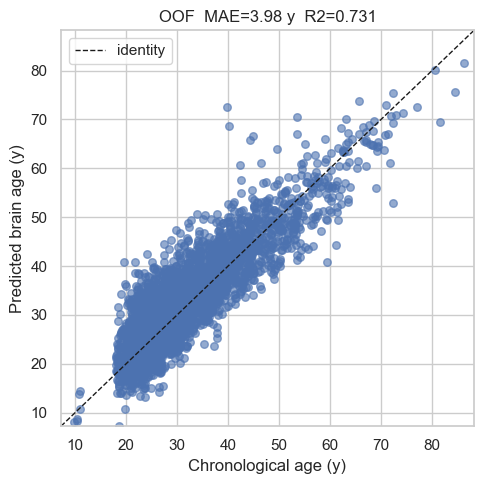

In [5]:
mae = mean_absolute_error(eval_df["AGE"], eval_df["predicted_age"])
r2 = r2_score(eval_df["AGE"], eval_df["predicted_age"])
corr = pearsonr(eval_df["AGE"], eval_df["predicted_age"])[0]
print(f"MAE:  {mae:.2f} years")
print(f"R2:   {r2:.3f}")
print(f"corr: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eval_df["AGE"], eval_df["predicted_age"], alpha=0.6, s=30)
lims = [eval_df["AGE"].min() - 2, eval_df["AGE"].max() + 2]
ax.plot(lims, lims, "k--", lw=1, label="identity")
ax.set_xlabel("Chronological age (y)")
ax.set_ylabel("Predicted brain age (y)")
ax.set_title(f"OOF  MAE={mae:.2f} y  R2={r2:.3f}")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Per-region diagnostics

`region_metrics` (stage-1 base-learner OOF, full-data fit) tells you which
regions are actually carrying signal vs noise before trusting any regional BAG.

                 r2            mae  correlation
count  8.320000e+02     832.000000   832.000000
mean  -2.492364e+09     324.108242     0.288998
std    7.151947e+10    8136.890417     0.246358
min   -2.062934e+12       6.884884    -0.081605
25%   -3.722094e+00       9.487403     0.053214
50%   -1.649754e+00      13.221208     0.312398
75%   -4.330261e-01      19.637075     0.534981
max    2.235824e-01  234140.342292     0.702309

regions with r2 < 0 (worse than predicting the mean): 802 / 832


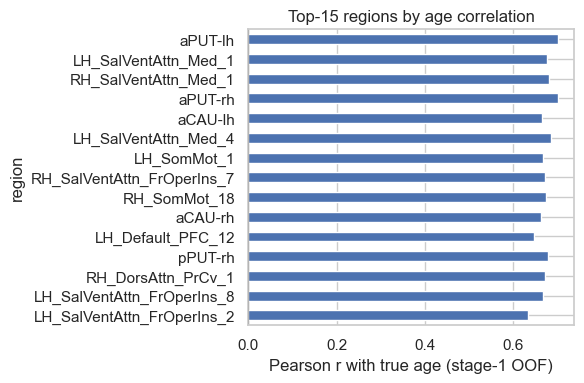

In [6]:
rm = result.region_metrics.sort_values("r2", ascending=False)
print(rm[["r2", "mae", "correlation"]].describe())
n_bad = (rm["r2"] < 0).sum()
print(f"\nregions with r2 < 0 (worse than predicting the mean): {n_bad} / {len(rm)}")

fig, ax = plt.subplots(figsize=(6, 4))
rm.set_index("region")["correlation"].head(15).plot.barh(ax=ax)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Pearson r with true age (stage-1 OOF)")
ax.set_title("Top-15 regions by age correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Bias correction: before vs after

`MultivariateRegionalBAGEstimator` already applies Cole/De Lange bias
correction (see `apply_bias_correction` in `_shared.py`) when
`cfg.bias_correction=True` (default). Compare `bag_uncorrected` vs `bag`.

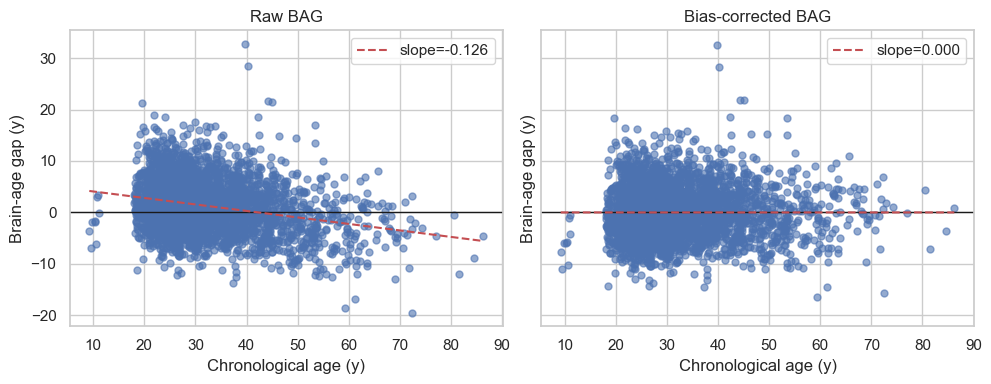

corr(age, bag_raw)      = -0.253
corr(age, bag_corrected) = 0.000


In [7]:
compare = (
    result.bag_uncorrected.rename(columns={"bag": "bag_raw"})
    .merge(result.bag.rename(columns={"bag": "bag_corrected"}), on=["uid", "session_id"])
    .merge(meta[["uid", "session_id", "AGE"]], on=["uid", "session_id"])
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col, title in zip(axes, ["bag_raw", "bag_corrected"], ["Raw BAG", "Bias-corrected BAG"]):
    ax.scatter(compare["AGE"], compare[col], alpha=0.6, s=25)
    ax.axhline(0, color="k", lw=1)
    m, b = np.polyfit(compare["AGE"], compare[col], 1)
    xs = compare["AGE"].sort_values()
    ax.plot(xs, m * xs + b, "r--", lw=1.5, label=f"slope={m:.3f}")
    ax.set_xlabel("Chronological age (y)")
    ax.set_ylabel("Brain-age gap (y)")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print(f"corr(age, bag_raw)      = {pearsonr(compare['AGE'], compare['bag_raw'])[0]:.3f}")
print(f"corr(age, bag_corrected) = {pearsonr(compare['AGE'], compare['bag_corrected'])[0]:.3f}")

## 6. BAG distribution and sex differences

Sanity-check the overall shape of the (bias-corrected) BAG and whether it
differs by sex - a common covariate check before trusting BAG as a
per-subject summary statistic.

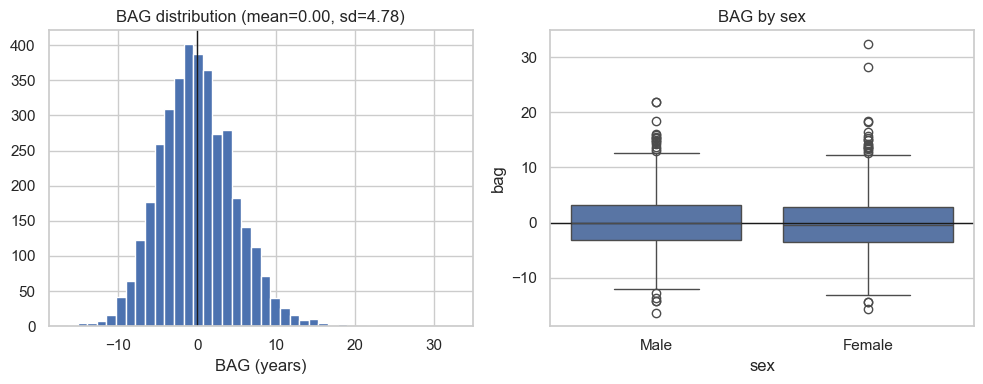

In [8]:
bag_df = result.bag.merge(meta[["uid", "session_id", "AGE", "sex"]], on=["uid", "session_id"]).dropna(subset=["AGE"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(bag_df["bag"], bins=40)
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("BAG (years)")
axes[0].set_title(f"BAG distribution (mean={bag_df['bag'].mean():.2f}, sd={bag_df['bag'].std():.2f})")

if "sex" in bag_df.columns and bag_df["sex"].notna().any():
    sns.boxplot(data=bag_df, x="sex", y="bag", ax=axes[1])
    axes[1].axhline(0, color="k", lw=1)
    axes[1].set_title("BAG by sex")
plt.tight_layout()
plt.show()

## 7. Most accelerated / decelerated subjects

The actual per-subject payoff of BAG: who ages faster or slower than expected,
by how much, and does it look plausible (extreme outliers may indicate
data-quality issues rather than real biology).

In [9]:
top_n = 15
cols = ["uid", "session_id", "AGE", "predicted_age", "bag"]
full_df = result.bag.merge(result.predicted_age, on=["uid", "session_id"]).merge(
    meta[["uid", "session_id", "AGE"]], on=["uid", "session_id"]
).dropna(subset=["AGE"])

print("Most 'older-looking' brains (highest BAG):")
display(full_df.sort_values("bag", ascending=False)[cols].head(top_n))

print("\nMost 'younger-looking' brains (lowest BAG):")
display(full_df.sort_values("bag")[cols].head(top_n))

Most 'older-looking' brains (highest BAG):


,uid,session_id,AGE,predicted_age,bag
1654,S430694,202409221915,39.740000,72.512535,32.447241
884,S229238,202501151037,40.224504,68.748829,28.260179
3664,S994485,202311081701,44.990000,66.537430,21.884714
1884,S493388,202408111024,44.290000,65.901941,21.860882
2533,S681070,202502231113,42.261465,60.735368,18.466832
2409,S645786,202311261422,53.470000,70.458988,18.396493
1719,S449321,202311151828,19.640000,40.819820,18.317801
1613,S418996,202207140825,21.850000,40.795000,16.361895
863,S221690,202211181133,24.060000,42.524243,16.160052
32,S010635,202511171904,29.878166,47.360239,15.912164



Most 'younger-looking' brains (lowest BAG):


,uid,session_id,AGE,predicted_age,bag
1926,S505233,202407160833,59.330000,40.800291,-16.382641
540,S134133,202111241238,72.440000,52.937769,-15.700612
508,S125082,202412111835,61.251198,44.378775,-14.482890
867,S224677,202210131916,37.330000,23.560885,-14.398563
3488,S940967,202408141455,18.540000,7.310127,-14.230718
1646,S426133,202107131113,26.410000,14.207116,-14.210494
1647,S426133,202205120832,27.240000,15.376305,-13.766554
861,S221341,202403140904,37.920000,25.335432,-13.139554
1411,S369120,202304031123,26.500000,15.365759,-13.130492
870,S225333,202306181113,23.800000,13.280596,-12.856409


## 8. Look up a specific subject

Swap `SUBJECT_UID` for any `uid` in the store to inspect their BAG history
across sessions (useful once the app/retrieval layer needs single-subject
drill-down).

In [10]:
SUBJECT_UID = full_df.iloc[0]["uid"]  # replace with a uid of interest

subject_history = full_df[full_df["uid"] == SUBJECT_UID].sort_values("session_id")
print(f"Subject: {SUBJECT_UID}  ({len(subject_history)} session(s))")
display(subject_history[cols])

Subject: S000091  (1 session(s))


,uid,session_id,AGE,predicted_age,bag
0,S000091,202206241117,31.15,33.532496,0.973099


## 9. Confirm visibility via `BAGStore`

Final check that this result is saved and discoverable the same way the
app/embedding layer will consume it.

In [11]:
print("BAG results now visible via BAGStore:", bag_store.list())
bag_store.load(f"multivariate/{BAG_NAME}").head()

BAG results now visible via BAGStore: ['multivariate/anat_baseline', 'univariate/AMICONODDI_noddi_direction_coverage', 'univariate/AMICONODDI_noddi_direction_cv', 'univariate/AMICONODDI_noddi_direction_excess_kurtosis', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_mean', 'univariate/AMICONODDI_noddi_direction_iqr_filtered_std', 'univariate/AMICONODDI_noddi_direction_mad_median', 'univariate/AMICONODDI_noddi_direction_mean', 'univariate/AMICONODDI_noddi_direction_median', 'univariate/AMICONODDI_noddi_direction_percentile_25', 'univariate/AMICONODDI_noddi_direction_percentile_5', 'univariate/AMICONODDI_noddi_direction_percentile_75', 'univariate/AMICONODDI_noddi_direction_percentile_95', 'univariate/AMICONODDI_noddi_direction_robust_cv', 'univariate/AMICONODDI_noddi_direction_robust_mean', 'univariate/AMICONODDI_noddi_direction_robust_std', 'univariate/AMICONODDI_noddi_direction_skewness', 'univariate/AMICONODDI_noddi_direction_std', 'univariate/AMICONODDI_noddi_direction_sum', 'u

,session_id,uid,subject_code,subject_code_bids,lab,scan_date,scan_tag,scan_number,protocol,study,group_label,mapping_complete,AGE,sex,weight_kg,height_m,dominant_hand,bag
0,202206241117,S000091,BB00032,None,SNBB,2022-06-24,None,1,The Base,SNBB,None,True,31.150000,Male,80.0,1.830,None,0.973099
1,202402051426,S000676,BB00787,None,SNBB,2024-02-05,None,2,The Base,SNBB,None,True,22.700000,Male,82.0,1.810,None,2.908815
2,202406171852,S000676,BB00787,None,SNBB,2024-06-17,None,2,The Base,SNBB,None,True,23.060000,Male,80.0,1.800,None,6.806475
3,202602151308,S000704,BJJ_P_14,None,YA,2026-02-15,Pre,1,SNBB_YA_Sport,YA_BJJ,Professional,True,54.162902,Male,72.5,1.714,None,-10.877096
4,202601291810,S001544,YBH10059,None,YBH,2026-01-29,None,1,SNBB_YBH,YBH_Research,N/A,True,29.338809,Female,67.0,1.570,None,3.607411


In [12]:
bag_dir

PosixPath('/home/galkepler/Projects/neuroalign/data/processed_full/bag/multivariate/anat_baseline')